# Variational Quantum Classifier (VQC) vs. Classical Support Vector Machine (SVC)

## Overview
This study implements a **Variational Quantum Classifier (VQC)** to perform supervised learning on a real-world dataset. The VQC is a type of **Quantum Neural Network (QNN)** that utilizes a variational circuit with trainable parameters. By leveraging the **Qiskit Sampler primitive**, we map classical data into a high-dimensional quantum feature space and optimize a parameterized ansatz to determine class boundaries.

This notebook provides a side-by-side comparison between the quantum VQC approach and a classical **RBF-Kernel Support Vector Machine (SVC)**.

**Date:** 6 Jan 2025

---

### Use Case: The Iris Dataset
We utilize the **Iris flower dataset**, a classic benchmark in machine learning. The goal is to classify species based on morphological features.

### Why this approach?
* **Hybrid Optimization:** VQC represents a hybrid quantum-classical algorithm where a classical optimizer (COBYLA) iteratively updates quantum circuit parameters.
* **QNN Architecture:** Unlike the Quantum Kernel SVC (which focuses on a static or trained kernel matrix), VQC functions like a neural network, where the "forward pass" is a quantum measurement and the "loss" is calculated classically.
* **Dimensionality Alignment:** By using Principal Component Analysis (PCA), we align the dataset features with the available qubit count, demonstrating how quantum models handle compressed feature representations.

---

In [1]:
# ============================================================================
# SETUP AND IMPORTS
# ============================================================================

# Standard libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pylab as plt
import time
from IPython.display import clear_output

# Scikit-learn for data handling and classical comparison
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Qiskit Machine Learning and Algorithms
from qiskit.circuit.library import zz_feature_map, real_amplitudes
from qiskit.primitives import StatevectorSampler
from qiskit_machine_learning.optimizers import COBYLA
from qiskit_machine_learning.utils import algorithm_globals
from qiskit_machine_learning.algorithms.classifiers import VQC

# Global Configuration
RANDOM_SEED = 42
algorithm_globals.random_seed = RANDOM_SEED

print("✓ Setup complete. Environment configured.")

✓ Setup complete. Environment configured.


In [2]:
# ============================================================================
# DATA PROCESSING & EXPLORATION
# ============================================================================

# Load dataset
iris_data = load_iris()
print(iris_data.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [3]:
features, labels = iris_data.data, iris_data.target

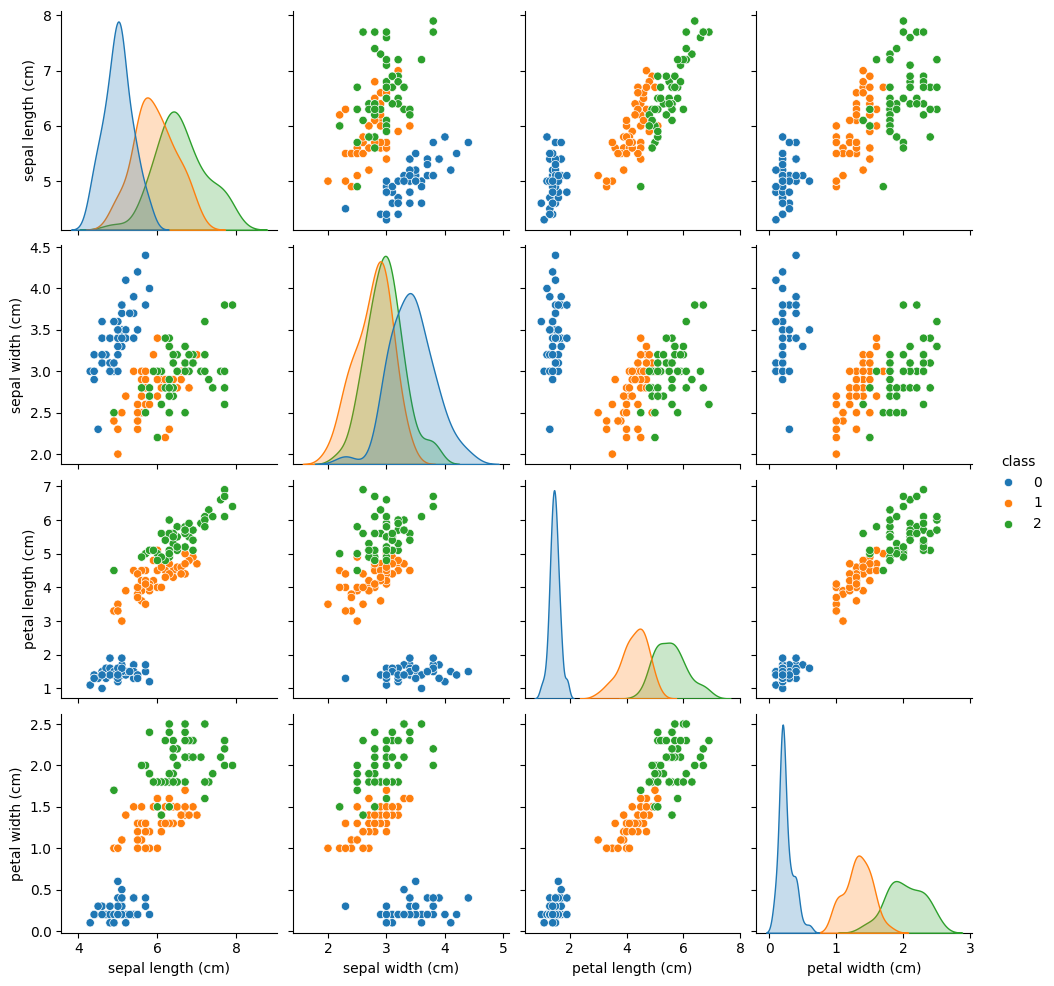

In [ ]:
# Exploring the dataset
df = pd.DataFrame(features, columns=iris_data.feature_names)
df["class"] = pd.Series(labels)

sns.pairplot(df, hue="class", palette="tab10")

#### Classcial Support Vector Classifier (SVC)

In [ ]:
# Split dataset in 80:20 for train:test purpose
train_features, test_features, train_labels, test_labels = train_test_split(
    features, labels, test_size=0.2, random_state=algorithm_globals.random_seed
)

In [6]:
# Train classical RBF SVC
print("Training Classical SVC (RBF)")
start_time = time.time()

svc = SVC(kernel='rbf')
svc.fit(train_features, train_labels)

classical_train_time = time.time() - start_time
print(f"Classical SVC training completed in {classical_train_time:.2f} seconds.")

Training Classical SVC (RBF)
Classical SVC training completed in 0.00 seconds.


In [7]:
# Evaluate metrics
svc_train_accuracy = svc.score(train_features, train_labels)
print(f"Classical SVC Train Accuracy: {svc_train_accuracy:.4f}")

svc_test_accuracy = svc.score(test_features, test_labels)
print(f"Classical SVC Test Accuracy: {svc_test_accuracy:.4f}")

Classical SVC Train Accuracy: 0.9750
Classical SVC Test Accuracy: 1.0000


#### Variational Quantum Classifier (VQC)

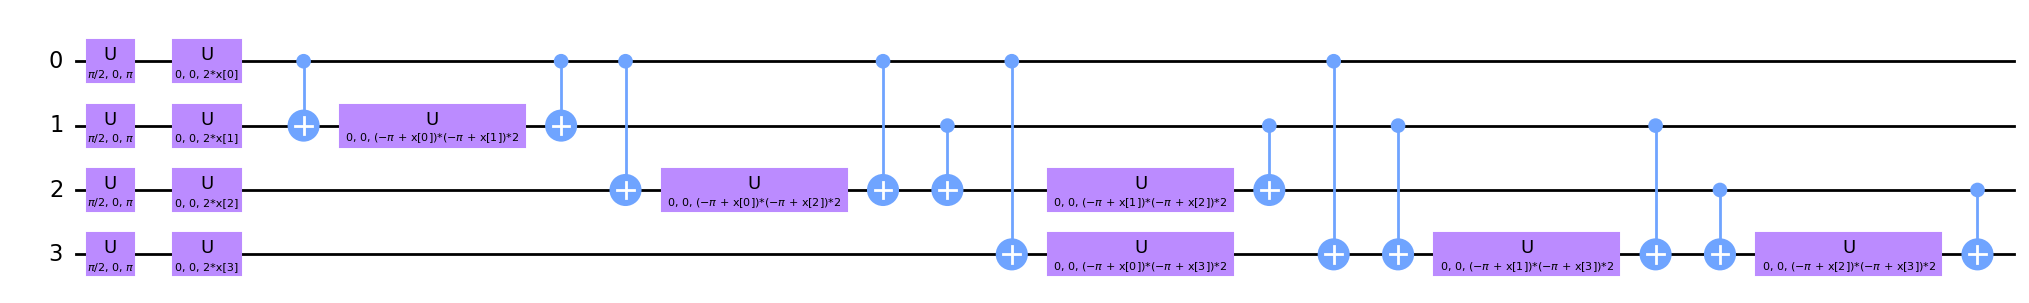

In [ ]:
# Define the feature_map for data encoding
num_features = features.shape[1]

feature_map = zz_feature_map(feature_dimension=num_features, reps=1)
feature_map.decompose().draw("mpl", style="clifford", fold=-1)

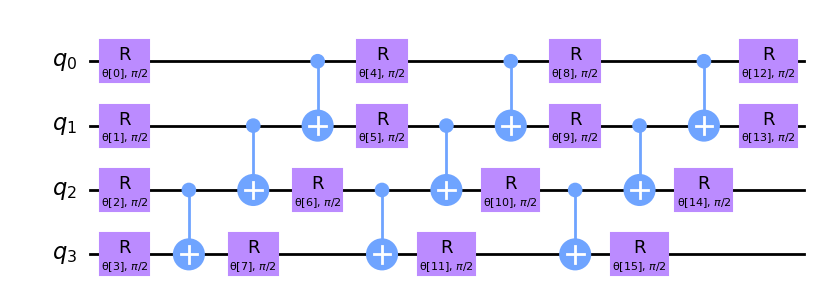

In [ ]:
# Define the ansatz 

ansatz = real_amplitudes(num_qubits=num_features, reps=3)
ansatz.decompose().draw("mpl", style="clifford", fold=-1)

In [ ]:
# Define the optimizer and the sampler
optimizer = COBYLA(maxiter=100)

sampler = StatevectorSampler()

In [11]:
objective_function_vals = []
plt.rcParams["figure.figsize"] = (10,6)

def callback_graph(weights, obj_func_eval):
    clear_output(wait=True)
    objective_function_vals.append(obj_func_eval)
    plt.title("Objective function value Vs Iteration")
    plt.xlabel("Iteration")
    plt.ylabel("Objective function value")
    plt.plot(range(len(objective_function_vals)), objective_function_vals)
    plt.show()

In [ ]:
# Define the VQC
vqc = VQC(
    sampler=sampler,
    feature_map=feature_map,
    ansatz=ansatz,
    optimizer=optimizer,
    callback=callback_graph,
)

No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


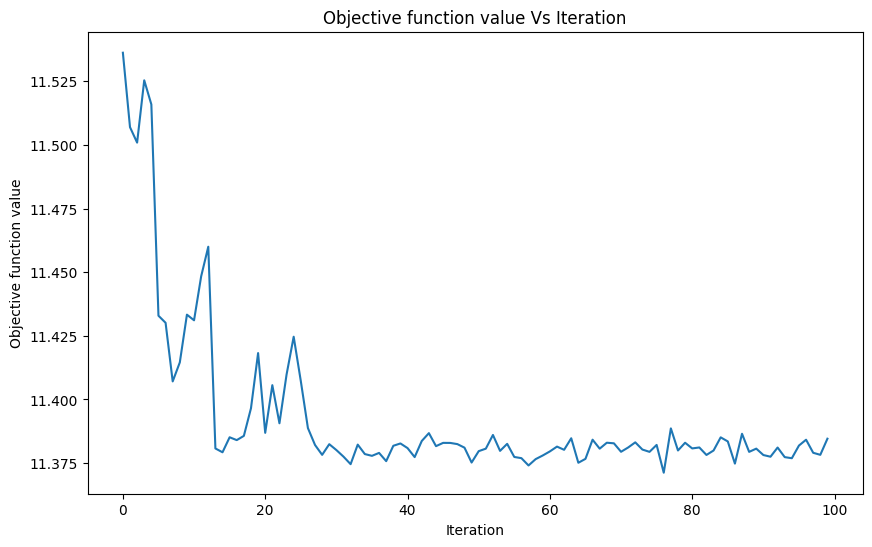

VQC training completed in 70.33 seconds.


In [ ]:
# Train the VQC
start_time = time.time()
vqc.fit(train_features, train_labels)
quantum_train_time = time.time() - start_time

print(f"VQC training completed in {quantum_train_time:.2f} seconds.")

In [ ]:
# Evaluate the metrics
vqc_train_accuracy = vqc.score(train_features, train_labels)
print(f"VQC Train Accuracy: {vqc_train_accuracy:.4f}")

vqc_test_accuracy = vqc.score(test_features, test_labels)
print(f"VQC Test Accuracy: {vqc_test_accuracy:.4f}")

VQC Train Accuracy: 0.4250
VQC Test Accuracy: 0.4333


### Evaluation using reduced features

<Axes: >

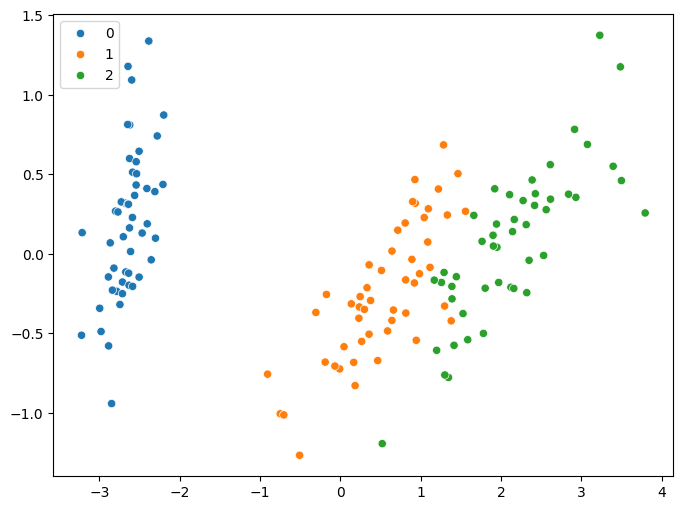

In [ ]:
# Reduce the features from 4 to 2
red_features = PCA(n_components=2).fit_transform(features)

plt.rcParams["figure.figsize"] = (8,6)
sns.scatterplot(x=red_features[:,0], y=red_features[:,1], hue=labels, palette="tab10")

#### Classical SVC

In [ ]:
# Split the data in 80:20
train_features, test_features, train_labels, test_labels = train_test_split(
    red_features, labels, test_size=0.2, random_state=algorithm_globals.random_seed
)

In [ ]:
# Train the classical SVC
svc = SVC(kernel='rbf')

start_time = time.time()
svc.fit(train_features, train_labels)
classical_train_time = time.time() - start_time
print(f"Classical SVC training completed in {classical_train_time:.2f} seconds.")

Classical SVC training completed in 0.00 seconds.


In [ ]:
# Evalute the metrics
svc_train_accuracy_2 = svc.score(train_features, train_labels)
print(f"Classical SVC Train Accuracy (2 features): {svc_train_accuracy_2:.4f}")

svc_test_accuracy_2 = svc.score(test_features, test_labels)
print(f"Classical SVC Test Accuracy (2 features): {svc_test_accuracy_2:.4f}")

Classical SVC Train Accuracy (2 features): 0.9583
Classical SVC Test Accuracy (2 features): 1.0000


#### Quantum VQC

In [ ]:
# Define the feature map for data encoding
num_features = red_features.shape[1]

feature_map = zz_feature_map(feature_dimension=num_features, reps=1)
ansatz = real_amplitudes(num_qubits=num_features, reps=3)

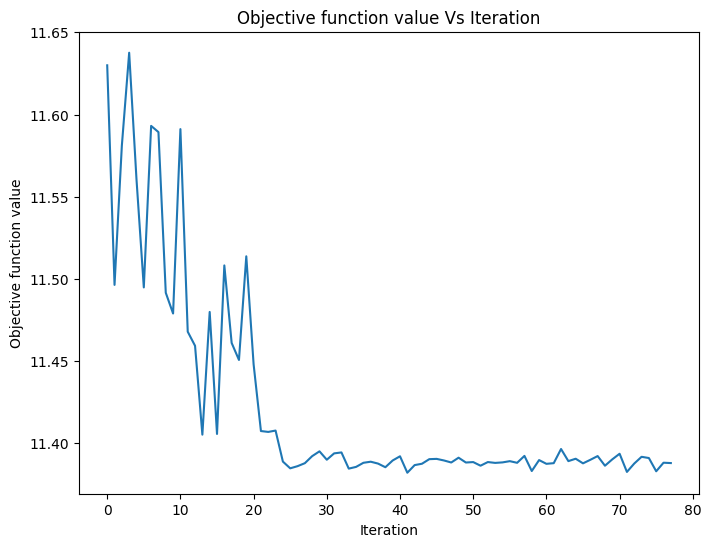

VQC training time (reduced features): 45.1645 seconds.


In [ ]:
# Define the VQC and train the same
vqc = VQC(
    sampler=sampler,
    feature_map = feature_map,
    ansatz = ansatz,
    optimizer = optimizer,
    callback=callback_graph,
)

objective_function_vals = []

start_time = time.time()
vqc.fit(train_features, train_labels)
quantum_train_time = time.time() - start_time

print(f"VQC training time (reduced features): {quantum_train_time:.4f} seconds.")

In [ ]:
# Evalute the metrics
vqc_train_accuracy_2 = vqc.score(train_features, train_labels)
print(f"Quantum VQC Train accuracy (2 features): {vqc_train_accuracy_2:.2f}")

vqc_test_accuracy_2 = vqc.score(test_features, test_labels)
print(f"Quantum VQC Test accuracy (2 features): {vqc_test_accuracy_2:.2f}")


Quantum VQC Train accuracy (2 features): 0.43
Quantum VQC Test accuracy (2 features): 0.37


#### Evaluating using Efficient_SU2 Ansatz

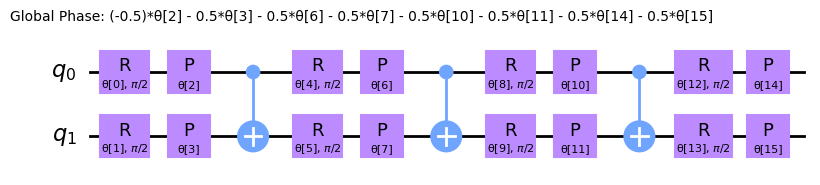

In [ ]:
# Import Efficient_SU2
from qiskit.circuit.library import efficient_su2

ansatz = efficient_su2(num_qubits=num_features, reps=3)
ansatz.decompose().draw("mpl", style="clifford", fold=-1)


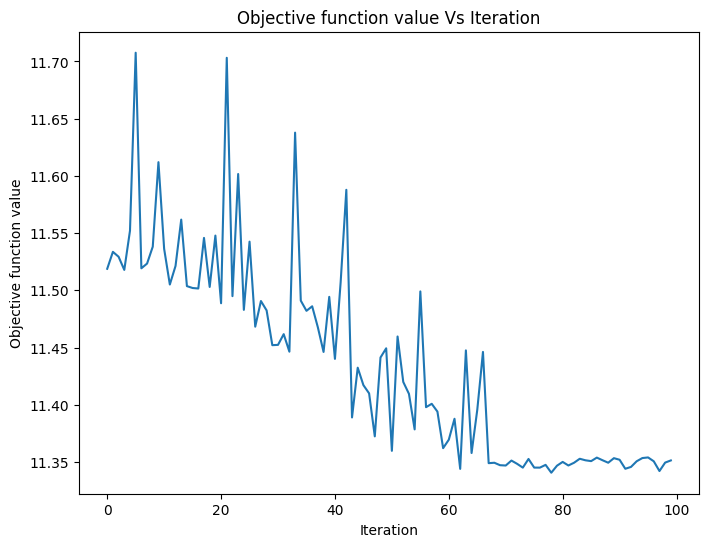

VQC training time (reduced features & eff_su2 ansatz): 55.8692 seconds.


In [ ]:
# Define the VQC and train the model
vqc = VQC(
    sampler=sampler,
    feature_map = feature_map,
    ansatz = ansatz,
    optimizer = optimizer,
    callback=callback_graph,
)

objective_function_vals = []

start_time = time.time()
vqc.fit(train_features, train_labels)
quantum_train_time = time.time() - start_time

print(f"VQC training time (reduced features & eff_su2 ansatz): {quantum_train_time:.4f} seconds.")

In [ ]:
# Evaluate the metrics
vqc_effSU2_train_accuracy = vqc.score(train_features, train_labels)
print(f"Quantum VQC Train accuracy (2 features & effSU2): {vqc_effSU2_train_accuracy:.2f}")

vqc_effSU2_test_accuracy = vqc.score(test_features, test_labels)
print(f"Quantum VQC Test accuracy (2 features & effSU2): {vqc_effSU2_test_accuracy:.2f}")

Quantum VQC Train accuracy (2 features & effSU2): 0.51
Quantum VQC Test accuracy (2 features & effSU2): 0.40


### Summary

In [25]:
print(f"Model                            | Test Score | Train Score")
print(f"SVC, 4 features                  | {svc_test_accuracy:10.2f} | {svc_train_accuracy:10.2f}")
print(f"VQC, 4 features, real_amplitudes | {vqc_test_accuracy:10.2f} | {vqc_train_accuracy:10.2f}")
print(f"-----------------------------------------------------------")
print(f"SVC, 2 features                  | {svc_test_accuracy_2:10.2f} | {svc_train_accuracy_2:10.2f}")
print(f"VQC, 2 features, real_amplitudes | {vqc_test_accuracy_2:10.2f} | {vqc_train_accuracy_2:10.2f}")
print(f"VQC, 2 features, efficient_su2   | {vqc_effSU2_test_accuracy:10.2f} | {vqc_effSU2_train_accuracy:10.2f}")

Model                            | Test Score | Train Score
SVC, 4 features                  |       1.00 |       0.97
VQC, 4 features, real_amplitudes |       0.43 |       0.42
-----------------------------------------------------------
SVC, 2 features                  |       1.00 |       0.96
VQC, 2 features, real_amplitudes |       0.37 |       0.43
VQC, 2 features, efficient_su2   |       0.40 |       0.51


## Conclusion and Observations

### 1. Performance Summary: Classical vs. Quantum Maturity

The classical model significantly outperformed its quantum counterparts. Classical ML has benefited from decades of optimization, whereas quantum ML has yet to reach that level of maturity. As observed in our results, we achieved perfect performance (1.00 test score) using a **Classical Support Vector Machine**. In contrast, the quantum models achieved test scores in the range of 0.37-0.43, highlighting the current gap between classical and quantum machine learning capabilities on this dataset.

### 2. The Impact of Feature Dimensionality

A notable observation was that feature reduction had minimal impact on model performance, particularly for the classical approach.

- **Classical Robustness**: The SVC maintained perfect test performance (1.00) even when features were reduced from 4 to 2, demonstrating that the classical model could effectively capture the decision boundary with fewer features.
- **Quantum Variations**: Feature reduction showed mixed effects on quantum models. The 4-feature VQC achieved a test score of 0.43, while 2-feature versions ranged from 0.37 to 0.40, suggesting that feature dimensionality has a relatively modest impact on quantum model performance in this case.
- **Practical Implication**: For this dataset, dimensionality reduction does not significantly compromise classical model accuracy, making it a viable option for resource-constrained scenarios.

### 3. Hyperparameter Criticality & Ansatz Choice

The choice of ansatz (variational circuit structure) showed modest differences in quantum model performance, though all quantum approaches remained significantly below classical performance.

- **Ansatz Comparison**: The `efficient_su2` ansatz achieved slightly better train performance (0.51) compared to `real_amplitudes` (0.43) for the 2-feature model, though test scores were comparable (0.40 vs 0.37).
- **Optimization Landscape**: The two-feature model with the efficient_su2 ansatz performs better than the one with real_amplitudes. That means the choice of hyperparameters plays the same critical role in quantum ML as in classical ML.